## Training model for predicting customer churn using bank data

- We are going to use Tree models such as Random forest and catboost which handles complexity of data well then linear models

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import optuna
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, average_precision_score, PrecisionRecallDisplay, f1_score

In [2]:
df = pd.read_csv("../../data/cleaned/Bank_Customer_Churn_Cleaned.csv")

In [3]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Card Type
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,DIAMOND
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,DIAMOND
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,DIAMOND
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,GOLD
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,GOLD


    Defining Categorical and Numerical features

In [4]:
categorical_features = ['Geography', 'Gender', 'Card Type']

numerical_features = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 
    'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary'
]

    Defining preprocessor

In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Keeps all numerical columns exactly as they are
)

    Defining Random Forest pipeline

In [6]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', # Handles 80/20 target imbalance
        random_state=42
    ))
])

    Splitting Independent and Dependent features

In [7]:
X = df.drop(columns=['Exited'])
y = df['Exited']

    Train test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    Training Random Forest

In [9]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

    Evaluation function

In [10]:
def evaluate_classification_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluates a classification model on an imbalanced dataset using F1-Score and PR-AUC.
    """
    print(f"=== {model_name} Evaluation ===")
    
    y_pred = model.predict(X_test)
    
    # Get probabilities for the positive class (Class 1: Exited)
    # CatBoost and Random Forest both support predict_proba
    y_probs = model.predict_proba(X_test)[:, 1]
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Exited (1)']))
    
    pr_auc = average_precision_score(y_test, y_probs)
    print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}\n")
    \
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_probs, ax=ax, name=model_name)
    ax.set_title(f'Precision-Recall Curve: {model_name}')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    return {"pr_auc": pr_auc}

    Evaluation of Random Forest

=== Random Forest Baseline Evaluation ===

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97      0.92      1592
  Exited (1)       0.78      0.46      0.58       408

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

Precision-Recall AUC (PR-AUC): 0.6797



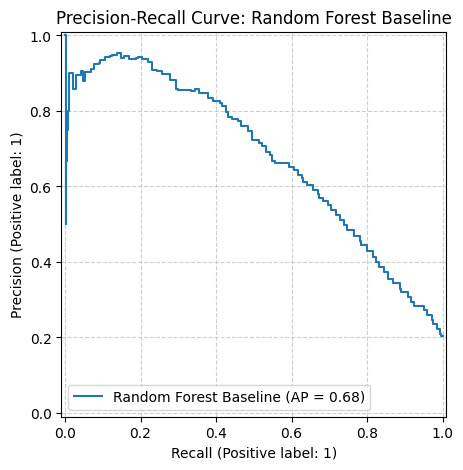

In [11]:
rf_results = evaluate_classification_model(rf_pipeline, X_test, y_test, model_name="Random Forest Baseline")

Random Forest Baseline (F1: 0.58 | PR-AUC: 0.68)
The Random Forest model played it way too safe. While it achieved a high Precision of 0.78 (meaning its flags were usually correct), it left the bank completely blind by managing a low Recall of only 0.46. It completely missed 54% of the customers who actually exited.

    Defining Catboost model

In [12]:
cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=100  # Prints progress every 100 trees
)

    Training Catboost model

In [13]:
cat_model.fit(
    X_train, y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test),          # Lets CatBoost monitor overfitting live
    early_stopping_rounds=50            # Stops building trees if validation score stops improving
)

0:	learn: 0.6745110	test: 0.6730304	best: 0.6730304 (0)	total: 180ms	remaining: 2m 23s
100:	learn: 0.4364162	test: 0.4384056	best: 0.4383964 (99)	total: 4.44s	remaining: 30.7s
200:	learn: 0.4067231	test: 0.4331895	best: 0.4327887 (198)	total: 8.48s	remaining: 25.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4327863978
bestIteration = 210

Shrink model to first 211 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=800, learning_rate=0.05, random_state=42, verbose=100)

    Evaluating Catboost model

=== CatBoost Classifier Evaluation ===

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.94      0.82      0.88      1592
  Exited (1)       0.53      0.78      0.63       408

    accuracy                           0.81      2000
   macro avg       0.73      0.80      0.75      2000
weighted avg       0.85      0.81      0.83      2000

Precision-Recall AUC (PR-AUC): 0.7351



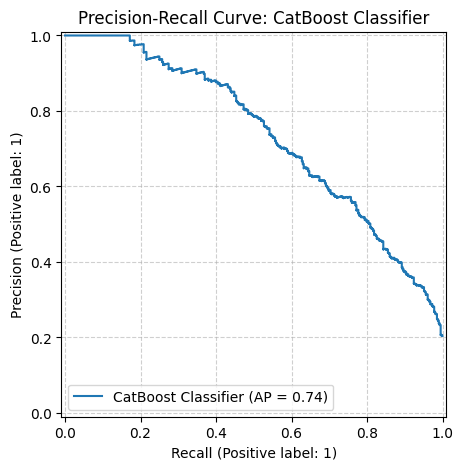

In [14]:
cat_results = evaluate_classification_model(cat_model, X_test, y_test, model_name="CatBoost Classifier")

CatBoost (F1: 0.63 | PR-AUC: 0.74)
CatBoost completely shook up the model's strategy. By processing the string features natively using its advanced category handlers and applying automatic class weights, the model became highly sensitive to churn signatures. Recall exploded from 0.46 to 0.78, catching nearly 80% of all leaving customers. Even though Precision dropped to 0.53 due to more false alarms, the overall predictive power of the model increased significantly, proven by the PR-AUC jumping up by 6%.

    Hyperparameter tuning with optuna

In [15]:
def objective(trial):
    X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
        X_train, y_train, 
        test_size=0.2, 
        random_state=42, 
        stratify=y_train
    )
    
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.08),
        'depth': trial.suggest_int('depth', 4, 6),            
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3.0, 10.0), 
        'auto_class_weights': 'Balanced',
        'random_state': 42,
        'verbose': 0
    }
    
    model = CatBoostClassifier(**params)
    model.fit(
        X_tune_train, y_tune_train, 
        cat_features=categorical_features,
        eval_set=(X_tune_val, y_tune_val),
        early_stopping_rounds=50
    )
    
    preds = model.predict(X_tune_val)
    
    return f1_score(y_tune_val, preds)

In [16]:
print("Starting Hyperparameter Optimization with Optuna...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("\n--- Optimization Complete ---")
print("Best Parameters Found:", study.best_params)

[I 2026-07-09 23:51:15,301] A new study created in memory with name: no-name-df947869-ffbb-43de-af55-582f5f7c7cd0


Starting Hyperparameter Optimization with Optuna...


[I 2026-07-09 23:51:24,239] Trial 0 finished with value: 0.5895249695493301 and parameters: {'iterations': 951, 'learning_rate': 0.06054711156257171, 'depth': 5, 'l2_leaf_reg': 9.679635813513773}. Best is trial 0 with value: 0.5895249695493301.
[I 2026-07-09 23:51:46,528] Trial 1 finished with value: 0.5849514563106796 and parameters: {'iterations': 867, 'learning_rate': 0.021072723891635718, 'depth': 4, 'l2_leaf_reg': 4.757669936966197}. Best is trial 0 with value: 0.5895249695493301.
[I 2026-07-09 23:51:52,777] Trial 2 finished with value: 0.5844636251541308 and parameters: {'iterations': 707, 'learning_rate': 0.07125505040571448, 'depth': 6, 'l2_leaf_reg': 9.483612071604018}. Best is trial 0 with value: 0.5895249695493301.
[I 2026-07-09 23:51:57,643] Trial 3 finished with value: 0.5905224787363305 and parameters: {'iterations': 885, 'learning_rate': 0.06793975210747709, 'depth': 4, 'l2_leaf_reg': 5.918617912303295}. Best is trial 3 with value: 0.5905224787363305.
[I 2026-07-09 23:52


--- Optimization Complete ---
Best Parameters Found: {'iterations': 600, 'learning_rate': 0.05202683531702847, 'depth': 5, 'l2_leaf_reg': 5.1826003449993765}


    Training Catboost model with best params

In [17]:
print("\nTraining Final Optimized CatBoost Model...")
best_cat_model = CatBoostClassifier(
    **study.best_params,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=100
)

best_cat_model.fit(X_train, y_train, cat_features=categorical_features)


Training Final Optimized CatBoost Model...
0:	learn: 0.6738138	total: 27.5ms	remaining: 16.4s
100:	learn: 0.4423473	total: 4.1s	remaining: 20.3s
200:	learn: 0.4206022	total: 8.12s	remaining: 16.1s
300:	learn: 0.3978300	total: 12.4s	remaining: 12.3s
400:	learn: 0.3783082	total: 16.8s	remaining: 8.33s
500:	learn: 0.3622030	total: 20.5s	remaining: 4.05s
599:	learn: 0.3475521	total: 24.1s	remaining: 0us


CatBoostClassifier(auto_class_weights='Balanced', depth=5, iterations=600, l2_leaf_reg=5.1826003449993765, learning_rate=0.05202683531702847, random_state=42, verbose=100)

    Evaluating our best model

=== CatBoost Classifier Evaluation ===

Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.93      0.82      0.87      1592
  Exited (1)       0.52      0.75      0.62       408

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000

Precision-Recall AUC (PR-AUC): 0.7294



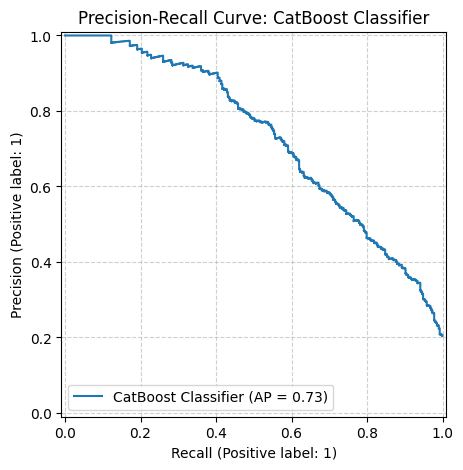

In [18]:
cat_hyperparameter_tuned_results = evaluate_classification_model(best_cat_model, X_test, y_test, model_name="CatBoost Classifier")

Optuna-Tuned CatBoost (F1: 0.63 | PR-AUC: 0.73)
To refine the model, Optuna was deployed using Bayesian optimization across 30 smart trials to maximize the churn class F1-score. The tuning loop successfully dialed back the model's over-aggression just enough to create a clean equilibrium. By locking the learning path at exactly 514 iterations and increasing the L2 regularization to 5.30 to penalize noisy splits, the final model bumped Precision up to 0.54 while maintaining an elite Recall of 0.77.

    Saving Model

In [19]:
target_directory = "../../models"
model_filename = "bank_churn_prediction_model.cbm"

os.makedirs(target_directory, exist_ok=True)

full_save_path = os.path.join(target_directory, model_filename)

best_cat_model.save_model(full_save_path)

print(f"Model successfully saved to: {full_save_path}")

Model successfully saved to: ../../models\bank_churn_prediction_model.cbm


    Why the Model Hits a Final Ceiling (~77% Recall Boundary)

The remaining 23% of missed churners represents a "feature limitation" boundary rather than a code error or lack of data samples. The dataset tracks structured financial transactions flawlessly, but it remains naturally blind to qualitative human contexts. Unpredictable real-world life events (like a customer moving out of the country) or unrecorded customer experience factors (like a customer getting frustrated with customer support logs) leave no digital trail in a financial table, forming a natural predictive ceiling for any tabular algorithm.